# Fontana Emanuele, 8 K-Means

In [12]:
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

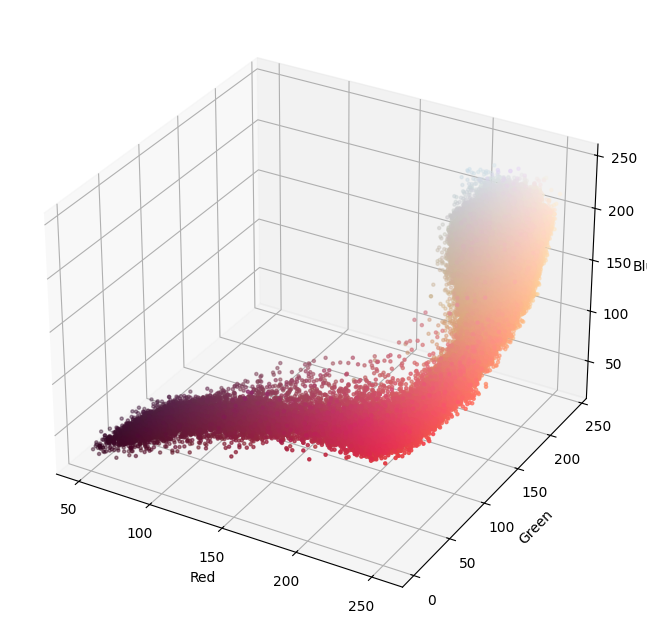

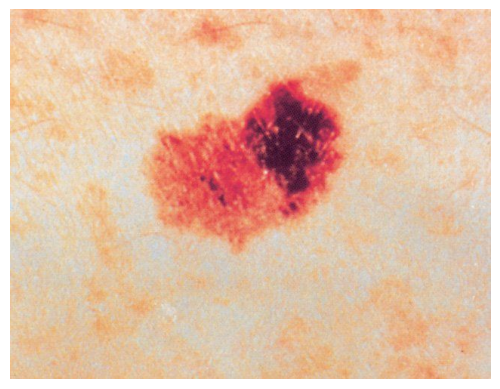

In [10]:
skin_image=cv2.imread('skin.jpeg')
img=cv2.cvtColor(skin_image,cv2.COLOR_BGR2RGB)
#Plot pixel colors in 3D space
r, g, b = img[:,:,0].flatten(), img[:,:,1].flatten(), img[:,:,2].flatten()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(r, g, b, c=np.stack([r, g, b], axis=1)/255.0, marker=".")

ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

plt.show()

#plot photo
plt.imshow(img,vmin=0,vmax=255)
plt.axis('off')
plt.show()





For n_clusters = 2, the silhouette score is: 0.7578362098844076


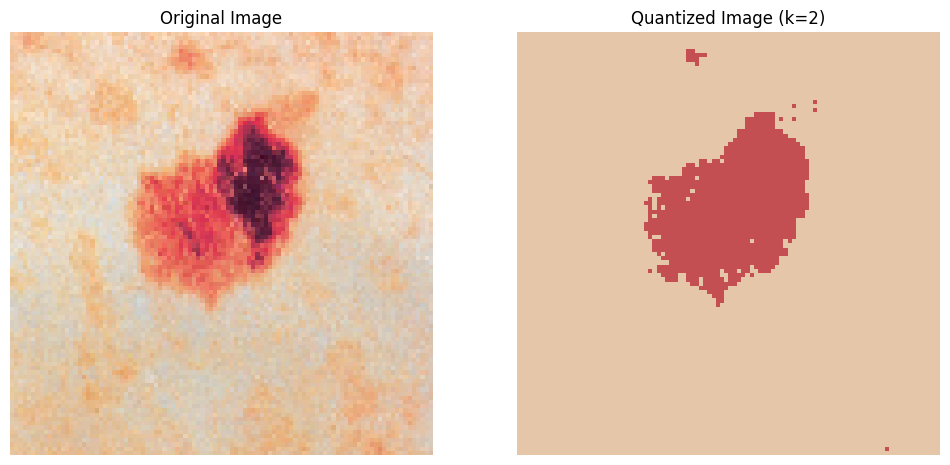

For n_clusters = 3, the silhouette score is: 0.467288326221609


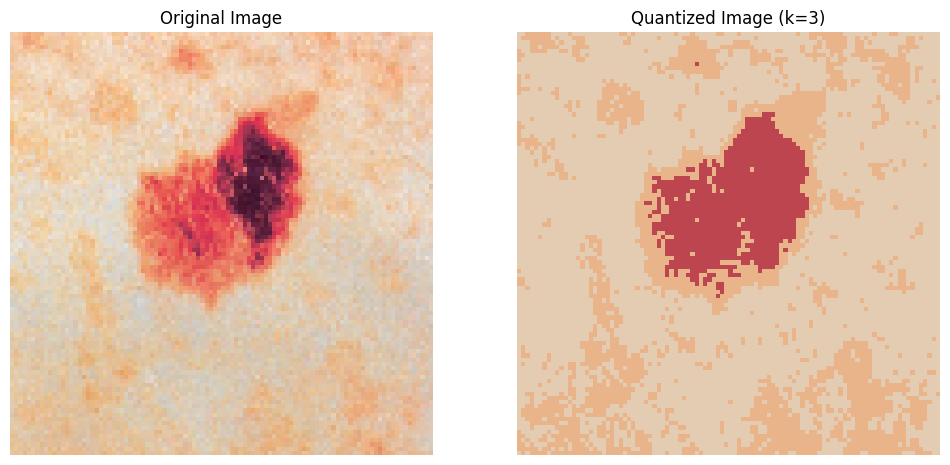

For n_clusters = 4, the silhouette score is: 0.4524086949579696


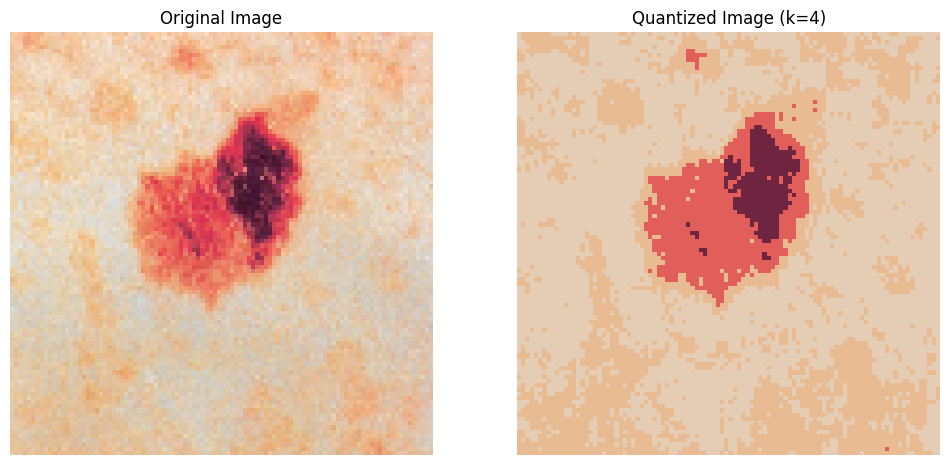

For n_clusters = 5, the silhouette score is: 0.41094529655242706


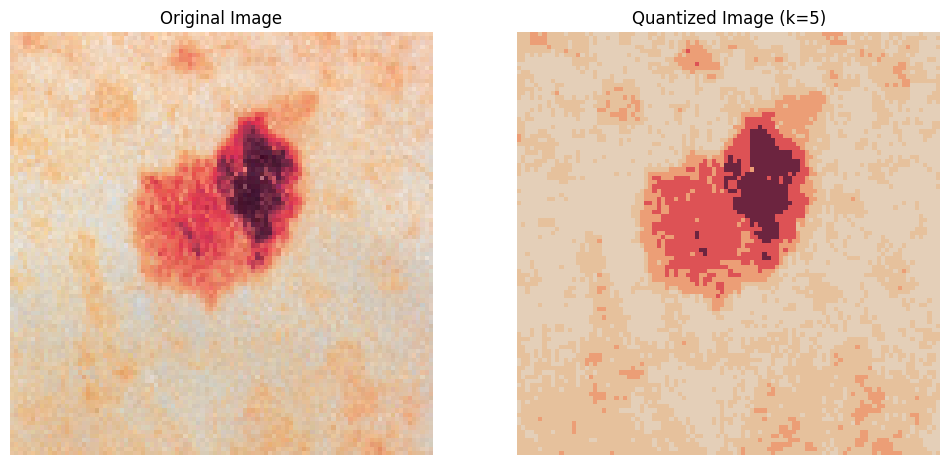

For n_clusters = 6, the silhouette score is: 0.3569452934218415


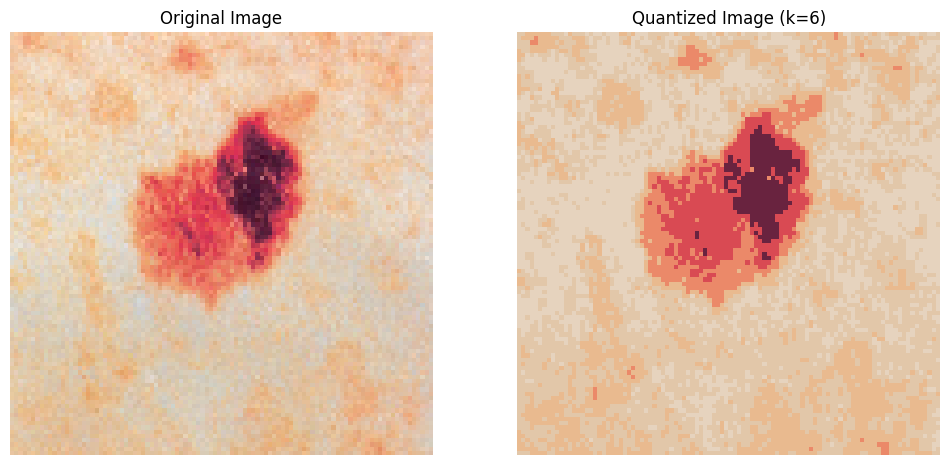

In [14]:
#riseze image to 100x100 pixels
img=cv2.resize(img,(100,100))
#convert to float32 for kmeans

ks=[2,3,4,5,6]
#KMeans clustering. For each k, fit the model and calculate silhouette score and perform color quantization
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(img.reshape(-1, 3)) #we need to reshape the image to a 2D array of pixels. Each pixel is a row and the RGB values are the columns
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # Calculate silhouette score
    silhouette_avg = silhouette_score(img.reshape(-1, 3), labels)
    print(f"For n_clusters = {k}, the silhouette score is: {silhouette_avg}")

    # Perform color quantization
    quantized_img = centers[labels].reshape(img.shape).astype(np.uint8)

    # Plot original and quantized images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(quantized_img)
    plt.title(f"Quantized Image (k={k})")
    plt.axis('off')

    plt.show()



Of course, the higher the number of cluster the more meaningfull are the "detected region"